In [40]:
from langgraph.graph import StateGraph,START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator
from langchain_core.exceptions import OutputParserException

In [52]:
class PydanticModel(BaseModel):
    feedback: str = Field(description="Detailed Description of feedback",min_length=20)
    score: int = Field(description="Give score in numeric format out between 1 and 10 (both included)",ge=0,le=10)

class State(TypedDict):
    essay: str
    feedback_doa : str
    feedback_cot : str
    feedback_col : str
    scores : Annotated[list[int], operator.add]
    feedback_final : str
    score_final : int


In [53]:
model= ChatOllama(
    model='qwen2.5:1.5b',
    temperature=0
)

model_2= ChatOllama(
    model='qwen2.5:1.5b',
    temperature=0,
    format='json'
)

structured_model = model_2.with_structured_output(PydanticModel)

In [99]:
def calculate_cot(state: State):
    prompt = prompt = f"""
Analyse the clarity of thought and coherence of the student's essay.
Assign a score between 1 and 10 and provide detailed feedback.
Essay:
{state['essay']}
"""
    
    max_retry = 5
    for i in range(max_retry):
        try:
            result = structured_model.invoke(prompt)
            if result.feedback and result.score is not None:
                return {"feedback_cot": result.feedback,"scores":[result.score]}
        
        except OutputParserException as e:
            print(f"Bad Json, Retrying COT {i}/{max_retry}")
    
    raise RuntimeError("Failed to obtain valid structured output.")
        
    


In [91]:
def calculate_doa(state: State):
    prompt = f"Analyse the Depth of Analysis in given essay and calculate score between 1 and 10:\n {state['essay']}"

    max_retry = 5
    for i in range(max_retry):
        try:
            result = structured_model.invoke(prompt)
            if result.feedback and result.score is not None:
                    return {"feedback_doa": result.feedback,"scores":[result.score]}

        
        except OutputParserException as e:
            print(f"Bad Json, Retrying DOA {i}/{max_retry}")
    
    raise RuntimeError("Failed to obtain valid structured output.")


In [92]:
def calculate_col(state: State):
    prompt = f"Analyse the clearity of language in given essay and calculate score between 1 and 10:\n {state['essay']}"
    result = structured_model.invoke(prompt)


    max_retry = 5
    for i in range(max_retry):
        try:
            result = structured_model.invoke(prompt)
            if result.feedback and result.score is not None:
                    return {"feedback_col": result.feedback,"scores":[result.score]}
        
        except OutputParserException as e:
            print(f"Bad Json, Retrying COL {i}/{max_retry}")
    
    raise RuntimeError("Failed to obtain valid structured output.")


In [93]:
def final_feedback(state: State):
    prompt = f"""
    Generate a summary of given data: 
    feedback for clariety of thoughts: {state['feedback_col']}
    feedback for depth of analysis: {state['feedback_doa']}
    feedback for clarity of thoughts: {state['feedback_cot']}
    """
    
    overall_feedback = model.invoke(prompt).content
    overall_score = sum(state['scores'])/len(state['scores'])

    return {"feedback_final":overall_feedback,"score_final":overall_score}

In [94]:
graph = StateGraph(State)

graph.add_node('calculate_cot',calculate_cot)
graph.add_node('calculate_doa',calculate_doa)
graph.add_node('calculate_col',calculate_col)
graph.add_node('final_feedback',final_feedback)

graph.add_edge(START,"calculate_cot")
graph.add_edge(START,"calculate_doa")
graph.add_edge(START,"calculate_col")

graph.add_edge("calculate_cot","final_feedback")
graph.add_edge("calculate_doa","final_feedback")
graph.add_edge("calculate_col","final_feedback")

graph.add_edge("final_feedback",END)


In [95]:
workflow = graph.compile()

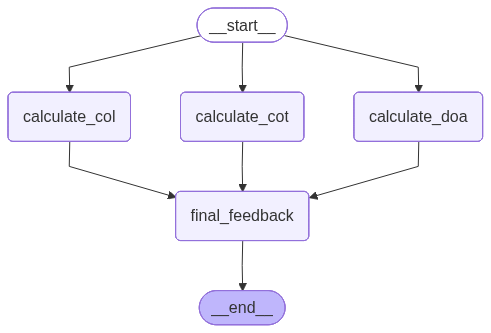

In [96]:
workflow

In [100]:
initial_state = {
    "essay" : """Artificial Intelligence in India

Artificial Intelligence (AI) has emerged as one of the most transformative technologies of the 21st century. It refers to the ability of machines and computer systems to perform tasks that normally require human intelligence, such as learning, reasoning, problem-solving, and decision-making. In India, AI is rapidly gaining importance and is playing a significant role in shaping the country's economic growth, technological advancement, and social development.

India has become one of the leading nations in adopting AI technologies. The government has recognized AI as a key driver of innovation and has launched several initiatives to promote its development. Programs such as Digital India, Make in India, and the National Strategy for Artificial Intelligence aim to encourage research, innovation, and the use of AI across various sectors. Government agencies are also investing in AI-based solutions to improve public services and governance.

AI is transforming many industries in India. In healthcare, AI helps doctors diagnose diseases, analyze medical images, and provide personalized treatment plans. In agriculture, AI-powered tools assist farmers in monitoring crop health, predicting weather patterns, and improving productivity. The education sector is benefiting from AI through personalized learning platforms, virtual tutors, and automated assessment systems. In banking and finance, AI is used for fraud detection, customer service, and risk management.

India's growing startup ecosystem has further accelerated AI adoption. Numerous startups and technology companies are developing innovative AI solutions in fields such as healthcare, education, e-commerce, and cybersecurity. Major technology firms are also investing heavily in AI research and development, creating employment opportunities for skilled professionals.

Despite its advantages, AI presents several challenges. Concerns about data privacy, cybersecurity, algorithmic bias, and job displacement need to be addressed. As automation increases, certain traditional jobs may be affected, making skill development and workforce reskilling essential. Ethical guidelines and regulatory frameworks are necessary to ensure the responsible use of AI.

The future of AI in India is promising. With a large pool of talented engineers, increasing digital infrastructure, and supportive government policies, India has the potential to become a global leader in AI innovation. By promoting responsible development and ensuring inclusive growth, AI can help solve complex societal problems and improve the quality of life for millions of people.

In conclusion, Artificial Intelligence is revolutionizing various sectors in India and creating new opportunities for growth and development. While challenges remain, the effective and ethical use of AI can contribute significantly to India's progress and strengthen its position in the global technological landscape.
"""
}
result = workflow.invoke(initial_state)

In [101]:
result

{'essay': "Artificial Intelligence in India\n\nArtificial Intelligence (AI) has emerged as one of the most transformative technologies of the 21st century. It refers to the ability of machines and computer systems to perform tasks that normally require human intelligence, such as learning, reasoning, problem-solving, and decision-making. In India, AI is rapidly gaining importance and is playing a significant role in shaping the country's economic growth, technological advancement, and social development.\n\nIndia has become one of the leading nations in adopting AI technologies. The government has recognized AI as a key driver of innovation and has launched several initiatives to promote its development. Programs such as Digital India, Make in India, and the National Strategy for Artificial Intelligence aim to encourage research, innovation, and the use of AI across various sectors. Government agencies are also investing in AI-based solutions to improve public services and governance.\